<a href="https://colab.research.google.com/github/pranay0729/NATURAL-LANGUAGE-PROCESSING/blob/main/NLP_ASSIGNMENT_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Install required libraries
!pip install nltk spacy wordcloud seaborn scikit-learn

# Import libraries
import pandas as pd
import re
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

# Download resources
nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")
stop_words = stopwords.words('english')

# Load dataset (update path if needed)
# The following line caused an error as it tried to read a PDF as a CSV.
# If you have a CSV file, replace this line with: df = pd.read_csv("your_file.csv")
# For now, we will use the dummy DataFrame created in a previous cell.
# df = pd.read_csv("/content/6_Why.pdf")

# Select one research domain (Computer Science)
# This line is not needed here as 'df' and 'abstracts' are already prepared by cell '4df127f0'
# df = df[df['category'].str.contains('cs', na=False)]
# abstracts = df['abstract'].dropna().head(5)

# Text preprocessing function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc
              if token.text not in stop_words and not token.is_stop]
    return " ".join(tokens)

# Clean abstracts
cleaned_abstracts = abstracts.apply(preprocess_text)

# TF-IDF computation
vectorizer = TfidfVectorizer(max_features=50)
tfidf_matrix = vectorizer.fit_transform(cleaned_abstracts)
feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

# Display TF-IDF feature list
print("TF-IDF Feature List:\n")
print(feature_names)

# Top 20 terms across corpus
top_20_terms = tfidf_df.mean().sort_values(ascending=False).head(20)
print("\nTop 20 TF-IDF Terms:\n")
print(top_20_terms)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


TF-IDF Feature List:

['achieve' 'advanced' 'agent' 'algorithm' 'analysis' 'apply' 'approach'
 'artificial' 'benchmark' 'black' 'classification' 'contribute'
 'convolutional' 'corpus' 'cosmic' 'datum' 'deep' 'detection' 'disease'
 'dynamic' 'early' 'environment' 'exploration' 'extraction' 'feature'
 'focus' 'gain' 'gravitational' 'hole' 'imaging' 'improved' 'intelligence'
 'language' 'large' 'learn' 'learning' 'leverage' 'machine' 'medical'
 'merger' 'model' 'natural' 'network' 'neural' 'new' 'novel' 'optimize'
 'paper' 'processing' 'technique']

Top 20 TF-IDF Terms:

analysis         0.116221
processing       0.116221
technique        0.115117
detection        0.115117
learn            0.106603
cosmic           0.081169
hole             0.081169
advanced         0.081169
contribute       0.081169
black            0.081169
gravitational    0.081169
merger           0.081169
environment      0.070369
dynamic          0.070369
artificial       0.070369
benchmark        0.070369
algorithm

### Word Cloud Visualization

This Word Cloud visualizes the top 20 TF-IDF terms across the corpus. The size of each word in the cloud is proportional to its TF-IDF score, indicating its relative importance. This provides a quick visual summary of the most prominent topics in the abstracts.

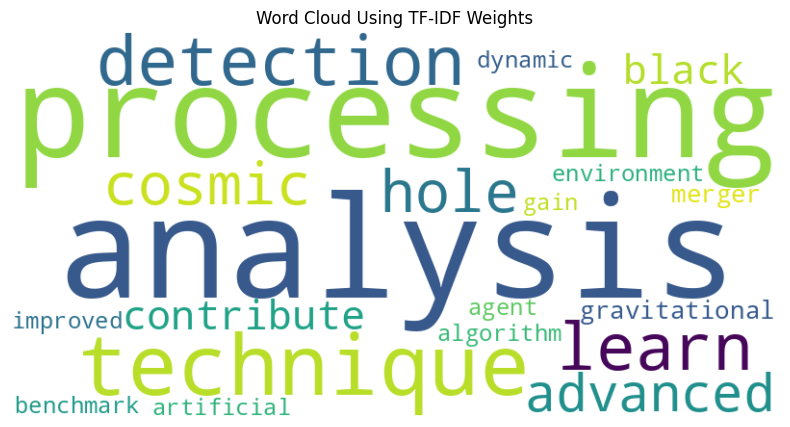

In [9]:
# Word Cloud visualization
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(top_20_terms)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Using TF-IDF Weights")
plt.show()

### TF-IDF Heatmap

This heatmap illustrates the TF-IDF scores for the top 10 terms across the five documents (abstracts). Darker shades represent higher TF-IDF values, indicating a stronger relevance of that term to a particular document. This helps in understanding the distribution and importance of key terms within each abstract.

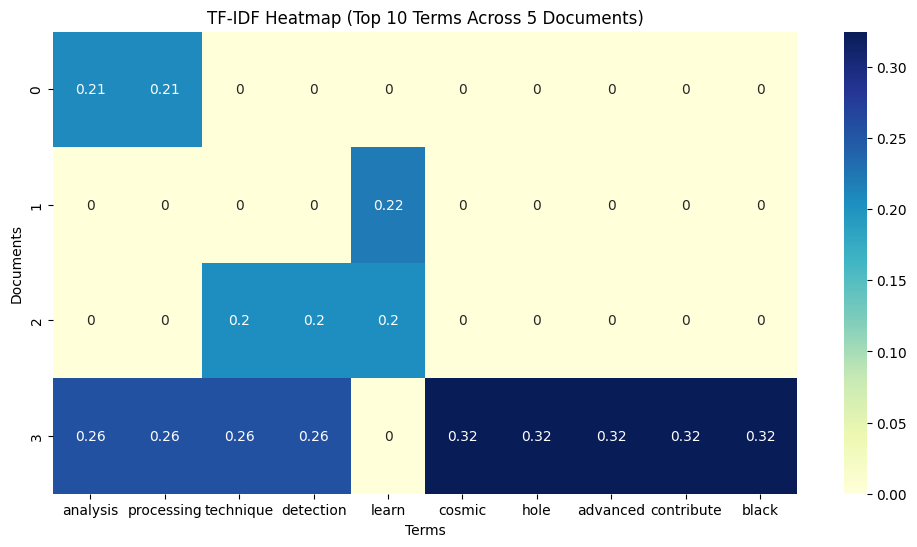

In [11]:
# Heatmap for top 10 terms across 5 documents
top_10_terms = top_20_terms.head(10).index
heatmap_data = tfidf_df[top_10_terms]

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu')
plt.title("TF-IDF Heatmap (Top 10 Terms Across 5 Documents)")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()